Shape: (108236, 18)
Index(['HR', 'HRV_RMSSD', 'RR_diff_std', 'HRV_SDNN', 'RR_mean', 'RR_std',
       'RR_min', 'RR_max', 'RR_count', 'RR_quality', 'RR_valid', 'EDA_Tonic',
       'EDA_Phasic', 'SCR_Rate', 'participant', 'time_sec', 'EDA_Tonic_log',
       'EDA_Phasic_log'],
      dtype='str')

=== DESCRIBE ===
                  HR      HRV_RMSSD    RR_diff_std       HRV_SDNN  \
count  108236.000000  108236.000000  108236.000000  108236.000000   
mean       79.562216      48.450728      48.139089      59.857868   
std        11.762024      17.194039      16.938379      25.955726   
min        52.600662       8.021961       8.017150      10.176887   
25%        71.387263      35.191782      35.101920      40.939412   
50%        78.188259      48.410542      48.206047      55.501708   
75%        86.338322      61.550642      61.048261      74.428992   
max       167.366956     108.512672     108.397417     200.000000   

             RR_mean         RR_std         RR_min         RR_max 

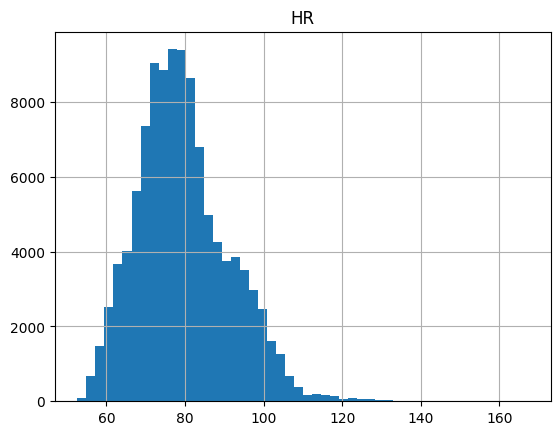

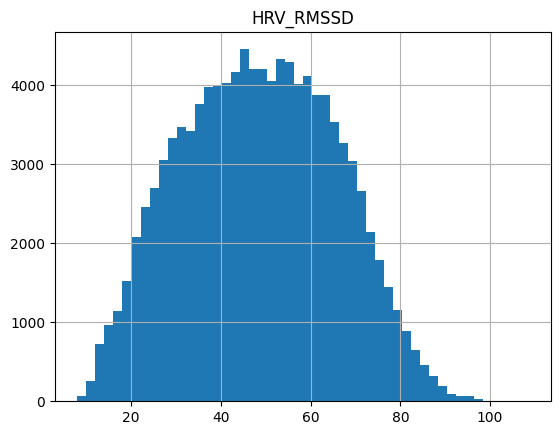

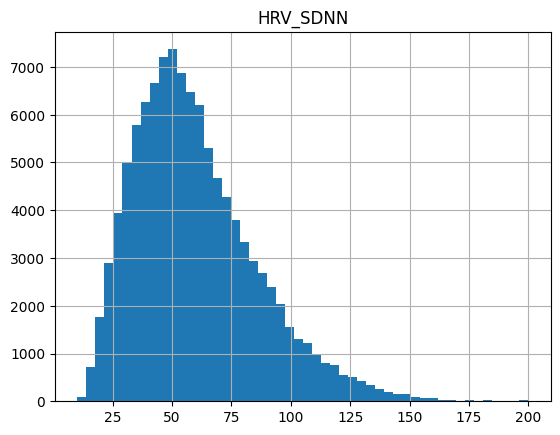

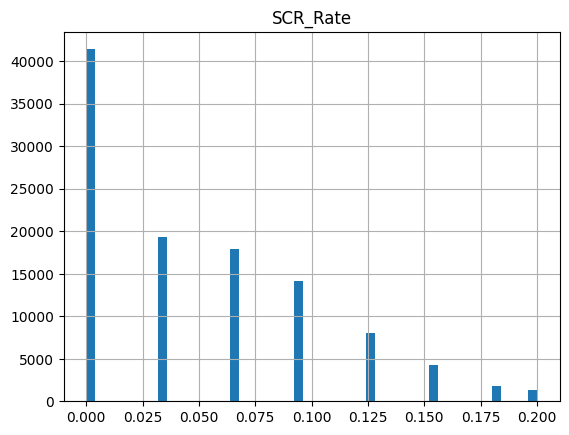

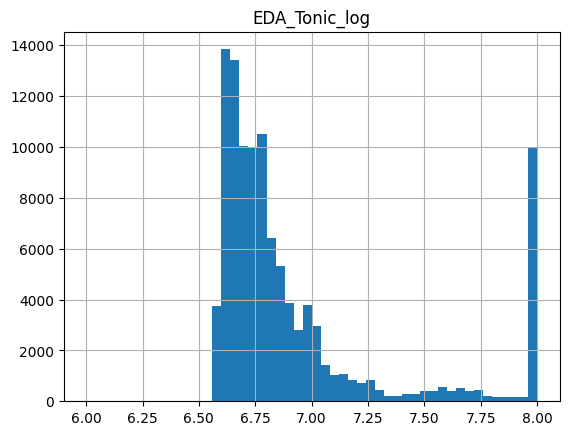

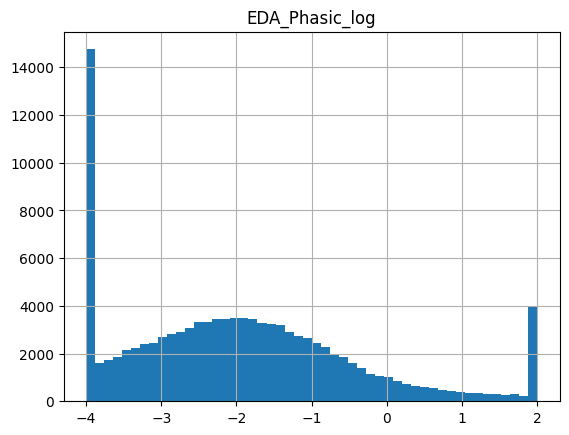


=== RANGE FLAGS ===
HR < 40: 0.0
HR > 150: 0.0002956502457592668
RMSSD > 120: 0.0
RMSSD < 10: 0.0005543442107986252
SDNN > 120: 0.02772644961011124
SDNN < 10: 0.0
SCR == 0: 0.3822850068369119


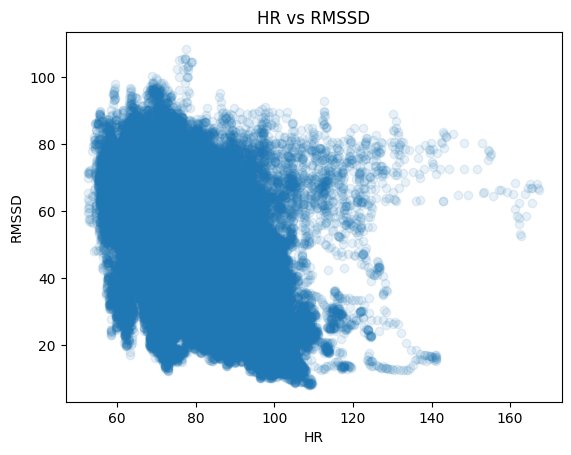


=== HRV NaN ratio ===
0.0

=== EXTREME RMSSD (>120) ===
Empty DataFrame
Columns: [HR, HRV_RMSSD, RR_diff_std, HRV_SDNN, RR_mean, RR_std, RR_min, RR_max, RR_count, RR_quality, RR_valid, EDA_Tonic, EDA_Phasic, SCR_Rate, participant, time_sec, EDA_Tonic_log, EDA_Phasic_log]
Index: []

=== EXTREME HR (<40 or >150) ===
            HR  HRV_RMSSD  RR_diff_std    HRV_SDNN     RR_mean      RR_std  \
14  153.446557  65.630427    58.817647  156.615281  697.884615  153.573918   
15  155.600122  64.498062    56.375724  159.083835  689.200000  155.869689   
16  157.049803  66.445466    55.190579  163.272425  668.269231  160.101784   
17  159.093488  65.688660    55.587768  163.304812  657.692308  160.133543   
18  161.285463  68.533751    56.527095  159.806462  641.481481  156.819162   

    RR_min  RR_max  RR_count  RR_quality  RR_valid   EDA_Tonic  EDA_Phasic  \
14   420.0   975.0        26    0.680000         1  521.012736    6.572669   
15   420.0   975.0        25    0.625000         1  530.00

In [6]:
# Feature Validity Check Notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# =========================
# LOAD DATA
# =========================
FILE_PATH = Path("../data/features_extraction_full_file_analys_RR_centroid.csv")  # ändra

df = pd.read_csv(FILE_PATH)

print("Shape:", df.shape)
print(df.columns)

# =========================
# BASIC STATS
# =========================
print("\n=== DESCRIBE ===")
print(df.describe())

print("\n=== NaN CHECK ===")
print(df.isna().mean())

# =========================
# HISTOGRAMS
# =========================
features = [
    "HR",
    "HRV_RMSSD",
    "HRV_SDNN",
    "SCR_Rate",
    "EDA_Tonic_log",
    "EDA_Phasic_log"
]

for f in features:
    plt.figure()
    df[f].hist(bins=50)
    plt.title(f)
    plt.show()

# =========================
# RANGE CHECKS
# =========================
print("\n=== RANGE FLAGS ===")

print("HR < 40:", (df["HR"] < 40).mean())
print("HR > 150:", (df["HR"] > 150).mean())

print("RMSSD > 120:", (df["HRV_RMSSD"] > 120).mean())
print("RMSSD < 10:", (df["HRV_RMSSD"] < 10).mean())

print("SDNN > 120:", (df["HRV_SDNN"] > 120).mean())
print("SDNN < 10:", (df["HRV_SDNN"] < 10).mean())

print("SCR == 0:", (df["SCR_Rate"] == 0).mean())

# =========================
# HR vs RMSSD
# =========================
plt.figure()
plt.scatter(df["HR"], df["HRV_RMSSD"], alpha=0.1)
plt.xlabel("HR")
plt.ylabel("RMSSD")
plt.title("HR vs RMSSD")
plt.show()


# =========================
# WINDOW QUALITY
# =========================
print("\n=== HRV NaN ratio ===")
print(df["HRV_RMSSD"].isna().mean())

# =========================
# EXTREME VALUES SAMPLE
# =========================
print("\n=== EXTREME RMSSD (>120) ===")
print(df[df["HRV_RMSSD"] > 120].head())

print("\n=== EXTREME HR (<40 or >150) ===")
print(df[(df["HR"] < 40) | (df["HR"] > 150)].head())

# =========================
# SUMMARY FLAGS
# =========================
print("\n=== QUICK SUMMARY ===")
print({
    "high_rmssd_ratio": float((df["HRV_RMSSD"] > 120).mean()),
    "low_hr_ratio": float((df["HR"] < 40).mean()),
    "high_hr_ratio": float((df["HR"] > 150).mean()),
    "scr_zero_ratio": float((df["SCR_Rate"] == 0).mean()),
    "nan_ratio": float(df["HRV_RMSSD"].isna().mean())
})



=== RR DESCRIBE ===
             RR_mean         RR_std         RR_min         RR_max  \
count  108236.000000  108236.000000  108236.000000  108236.000000   
mean      773.029877      59.063043     643.852369     913.745196   
std       106.700787      25.587180     111.017178     130.721666   
min       427.734375      10.083945     405.000000     460.000000   
25%       698.837209      40.416072     565.000000     825.000000   
50%       769.487179      54.762246     650.000000     915.000000   
75%       841.250000      73.410045     715.000000    1005.000000   
max      1129.565217     206.125658    1005.000000    1195.000000   

            RR_count    RR_diff_std  RR_valid  
count  108236.000000  108236.000000  108236.0  
mean       39.366191      48.139089       1.0  
std         5.579251      16.938379       0.0  
min        21.000000       8.017150       1.0  
25%        36.000000      35.101920       1.0  
50%        39.000000      48.206047       1.0  
75%        43.000000 

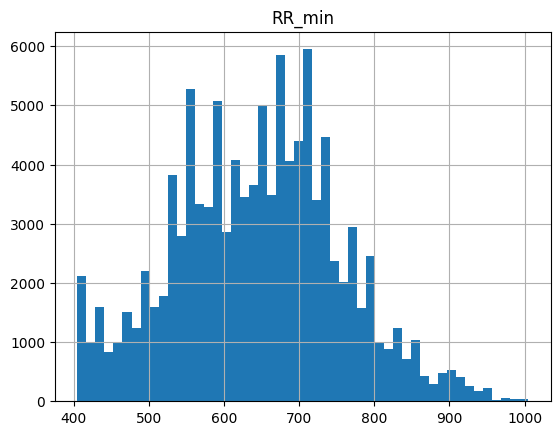

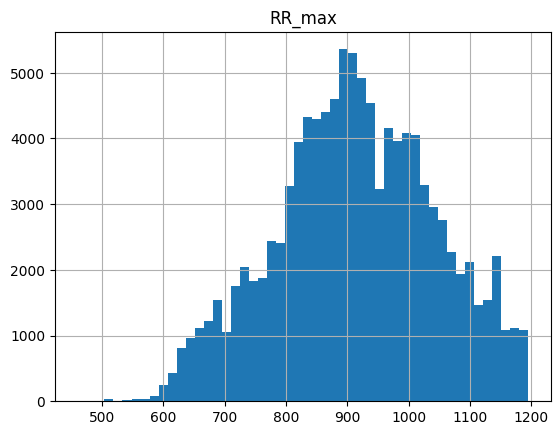

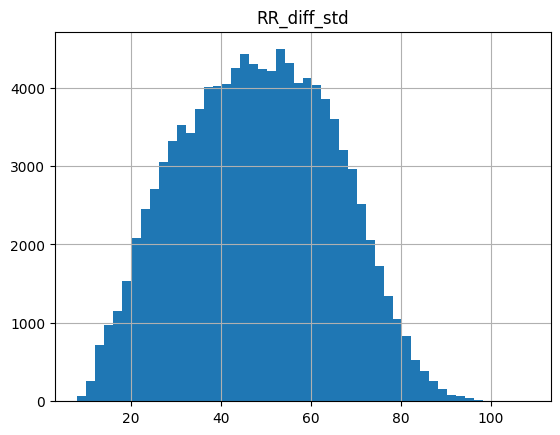


=== HR vs RR consistency ===
Mean error (bpm): 0.5424624123874988
Median error (bpm): 0.1011432372441945


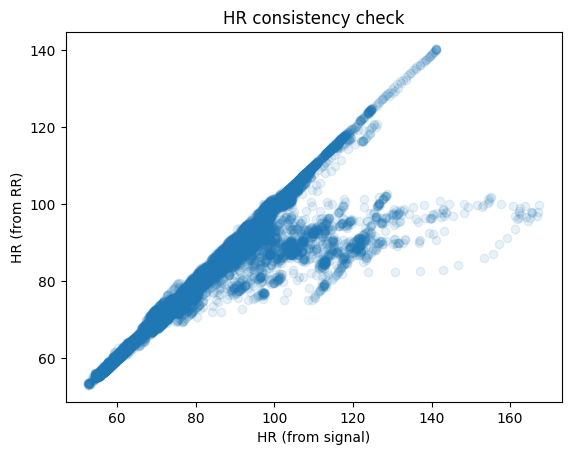


=== BAD WINDOWS SAMPLE ===
Number of bad windows: 15
Ratio: 0.0001385860526996563

Sample:
              HR   HRV_RMSSD  RR_diff_std    HRV_SDNN     RR_mean      RR_std  \
76133  75.292126  102.572183   102.408665  135.964562  798.552632  134.163627   
76134  75.762838  105.323575   105.191257  145.600793  807.236842  143.672221   
76135  76.361504  105.482522   105.470949  149.629436  808.055556  147.536614   
76136  76.784841  102.397725   102.396036  146.706204  801.891892  144.710108   
76137  77.181965  105.795307   105.171634  148.431615  800.000000  146.412044   

       RR_min  RR_max  RR_count  RR_quality  RR_valid  EDA_Tonic  EDA_Phasic  \
76133   530.0  1055.0        38    0.513514         1  96.938233    0.129325   
76134   530.0  1120.0        38    0.486486         1  96.670314    0.137542   
76135   530.0  1120.0        36    0.457143         1  96.390491    0.241405   
76136   530.0  1120.0        37    0.472222         1  96.100967    0.226812   
76137   530.0  1120.0

In [7]:
# =========================
# RR / IBI VALIDITY CHECK
# =========================

rr_features = [
    "RR_mean",
    "RR_std",
    "RR_min",
    "RR_max",
    "RR_count",
    "RR_diff_std",
    "RR_valid"
]

print("\n=== RR DESCRIBE ===")
print(df[rr_features].describe())

# -------------------------
# Range checks
# -------------------------
print("\n=== RR RANGE FLAGS ===")

print("RR_min < 300 ms:", (df["RR_min"] < 300).mean())
print("RR_max > 1500 ms:", (df["RR_max"] > 1500).mean())

print("RR_diff_std > 100:", (df["RR_diff_std"] > 100).mean())

print("RR_valid == 0:", (df["RR_valid"] == 0).mean())

# -------------------------
# Histograms
# -------------------------
import matplotlib.pyplot as plt

for f in ["RR_min", "RR_max", "RR_diff_std"]:
    plt.figure()
    df[f].hist(bins=50)
    plt.title(f)
    plt.show()

# -------------------------
# HR consistency check
# -------------------------
df["HR_from_RR"] = 60000 / df["RR_mean"]

error = np.abs(df["HR"] - df["HR_from_RR"])

print("\n=== HR vs RR consistency ===")
print("Mean error (bpm):", error.mean())
print("Median error (bpm):", np.median(error))

plt.figure()
plt.scatter(df["HR"], df["HR_from_RR"], alpha=0.1)
plt.xlabel("HR (from signal)")
plt.ylabel("HR (from RR)")
plt.title("HR consistency check")
plt.show()

# -------------------------
# Problematic windows
# -------------------------
print("\n=== BAD WINDOWS SAMPLE ===")

bad_windows = df[
    (df["RR_min"] < 300) |
    (df["RR_max"] > 1500) |
    (df["RR_diff_std"] > 100)
]

print("Number of bad windows:", len(bad_windows))
print("Ratio:", len(bad_windows) / len(df))

print("\nSample:")
print(bad_windows.head())

<Axes: >

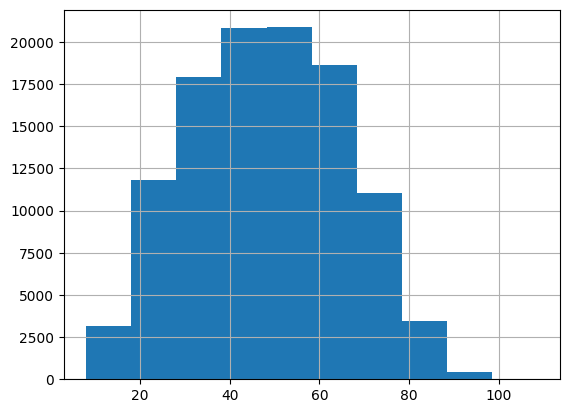

In [8]:
df["HRV_RMSSD"].describe()
df["HRV_RMSSD"].hist()

In [ ]:
df["HRV_RMSSD"].describe()